In [48]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [49]:
df = pd.read_csv("rice_crop_health_200k.csv")
print(df.head())
print(df.info())

    record_id        date  season       region    rice_variety growth_stage  \
0  RICE000001  2020-05-10  Kharif  West_Bengal  Pusa_Basmati_1     Seedling   
1  RICE000002  2021-07-18  Kharif      Haryana            IR64     Seedling   
2  RICE000003  2021-02-04  Kharif       Punjab          Swarna     Ripening   
3  RICE000004  2020-12-31    Rabi      Haryana  Pusa_Basmati_1    Flowering   
4  RICE000005  2022-06-27    Boro        Assam            IR64     Seedling   

   crop_age_days  field_area_ha   soil_type  soil_pH  ...  \
0            136          10.44       Loamy     7.66  ...   
1             55          18.56   Clay_Loam     5.79  ...   
2            113          16.28    Alluvial     6.22  ...   
3              1          14.29  Silty_Clay     6.49  ...   
4            105           1.09        Clay     6.41  ...   

   actual_yield_ton_ha  msp_INR_per_ton  treatment_cost_INR_ha  \
0                 3.35          21719.0                 3023.0   
1                 7.97    

In [50]:
data = df.copy()

In [51]:
drop_cols = [
    'record_id', 'date',
    'confidence_score',
    'economic_loss_INR_ha',
    'benefit_cost_ratio',
    'treatment_cost_INR_ha',
    'actual_yield_ton_ha'
]

data = data.drop(columns=drop_cols, errors='ignore')

In [52]:
# Encode target
target_col = 'intervention_flag'

encoder = LabelEncoder()
data[target_col] = encoder.fit_transform(data[target_col])

print(data[target_col].value_counts())


intervention_flag
1    135689
0     64311
Name: count, dtype: int64


In [53]:
#fix class imbalance
from sklearn.utils import resample
df_majority = data[data[target_col] == 1]
df_minority = data[data[target_col] == 0]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

data_balanced = pd.concat([df_majority, df_minority_upsampled])

print(data_balanced[target_col].value_counts())

intervention_flag
1    135689
0    135689
Name: count, dtype: int64


In [54]:
important_cols = [
    'soil_type',
    'soil_pH',
    'temperature_avg_C',
    'humidity_pct',
    'rainfall_mm',
    'soil_moisture_pct',
    'pest_severity_score',
    'disease_severity_score',
    'pest_incidence_pct',
    'disease_incidence_pct',
    'lesion_area_pct',
    'alert_level',
    'urgency_score'
]

In [55]:
#separate features and target class
x = data_balanced[important_cols]
y = data_balanced[target_col]

In [56]:
# Encode categorical features
encoders = {}

for col in x.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))
    encoders[col] = le

C:\Users\Pramana\AppData\Local\Temp\ipykernel_17204\2830176260.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col].astype(str))
C:\Users\Pramana\AppData\Local\Temp\ipykernel_17204\2830176260.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col].astype(str))


In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [58]:
input_df = data_balanced[data_balanced[target_col] == 0].sample(1)
input_df = input_df[important_cols]

print(input_df)

      soil_type  soil_pH  temperature_avg_C  humidity_pct  rainfall_mm  \
58834  Alluvial     6.08               24.9          75.3          0.0   

       soil_moisture_pct  pest_severity_score  disease_severity_score  \
58834              33.44                  1.4                     2.8   

       pest_incidence_pct  disease_incidence_pct  lesion_area_pct alert_level  \
58834                55.5                   39.2             2.21      Yellow   

       urgency_score  
58834           1.59  


In [59]:
encoder = {}

for col in input_df.select_dtypes(include='object').columns:
    le1 = LabelEncoder()
    input_df[col] = le1.fit_transform(input_df[col].astype(str))
    encoder[col] = le1

In [60]:
# Train naive bayes model
from sklearn.naive_bayes import GaussianNB
model1=GaussianNB()
model1.fit(x_train, y_train)


# Predictions
y_pred1 = model1.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred1)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred1),'\n')


#predict on new data
print('Prediction on new data using naive bayes:')
prediction1=model1.predict(input_df)
if prediction1[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

Accuracy: 92 

Confusion Matrix:
 [[24400  2695]
 [ 1377 25804]] 

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92     27095
           1       0.91      0.95      0.93     27181

    accuracy                           0.92     54276
   macro avg       0.93      0.92      0.92     54276
weighted avg       0.93      0.92      0.92     54276
 

Prediction on new data using naive bayes:
Non healthy crop


In [61]:
from sklearn.neighbors import KNeighborsClassifier
model2=KNeighborsClassifier(n_neighbors=5,metric='euclidean')
model2.fit(x_train,y_train)

# Predictions
y_pred2 = model2.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred2)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred2),'\n')


#predict on new data
print('Prediction on new data using KNN:')
prediction2=model2.predict(input_df)
if prediction2[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

Accuracy: 86 

Confusion Matrix:
 [[24101  2994]
 [ 4866 22315]] 

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86     27095
           1       0.88      0.82      0.85     27181

    accuracy                           0.86     54276
   macro avg       0.86      0.86      0.86     54276
weighted avg       0.86      0.86      0.86     54276
 

Prediction on new data using KNN:
Non healthy crop


Accuracy: 99 

Confusion Matrix:
 [[26907   188]
 [  182 26999]] 

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     27095
           1       0.99      0.99      0.99     27181

    accuracy                           0.99     54276
   macro avg       0.99      0.99      0.99     54276
weighted avg       0.99      0.99      0.99     54276
 



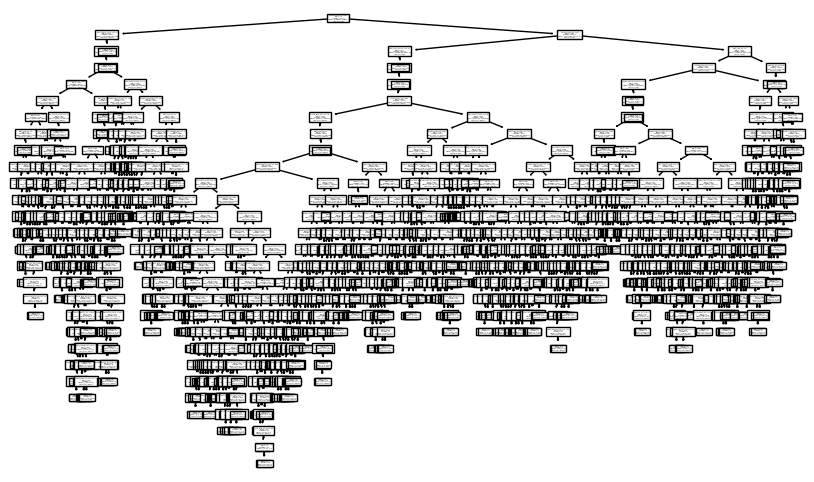

Prediction on new data using decision tree:
Non healthy crop


In [62]:
#train decision tree model
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

model3 = DecisionTreeClassifier(
    max_depth=None,         
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
model3.fit(x_train,y_train)

# Predictions
y_pred3 = model3.predict(x_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred3)*100),'\n')

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3),'\n')

#classification report
print('Classification report:\n',classification_report(y_test,y_pred3),'\n')


plt.figure(figsize=(10,6))
plot_tree(model3,feature_names=x.columns,class_names=['Non-Healthy','Healthy'])
plt.show()

#predict on new data
print('Prediction on new data using decision tree:')
prediction3=model3.predict(input_df)
if prediction3[0]==0:
    print('Non healthy crop')
else:
    print('Healthy crop')

In [63]:
from collections import Counter

print("Ensemble Prediction:")
predictions = [prediction1[0], prediction2[0], prediction3[0]]
ensemble_num = Counter(predictions).most_common(1)[0][0]
if ensemble_num==0:
    print('Unhealthy crop')
else:
    print('Healthy crop')

Ensemble Prediction:
Unhealthy crop


In [64]:
# Use original dataset
data_treat = df.copy()

# Target
y_treat = data_treat['recommended_action']

# Use only important columns
important_cols = [
    'soil_type',
    'soil_pH',
    'temperature_avg_C',
    'humidity_pct',
    'rainfall_mm',
    'soil_moisture_pct',
    'pest_severity_score',
    'disease_severity_score',
    'pest_incidence_pct',
    'disease_incidence_pct',
    'lesion_area_pct',
    'alert_level',
    'urgency_score'
]

x_treat = data_treat[important_cols]

# Encode categorical

encoders_treat = {}
for col in x_treat.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x_treat[col] = le.fit_transform(x_treat[col].astype(str))
    encoders_treat[col] = le

# Train model
from sklearn.ensemble import RandomForestClassifier

treatment_model = RandomForestClassifier(n_estimators=50, random_state=42)

C:\Users\Pramana\AppData\Local\Temp\ipykernel_17204\20808898.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_treat[col] = le.fit_transform(x_treat[col].astype(str))
C:\Users\Pramana\AppData\Local\Temp\ipykernel_17204\20808898.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_treat[col] = le.fit_transform(x_treat[col].astype(str))


In [65]:
treatment_encoder = LabelEncoder()
y_treat = treatment_encoder.fit_transform(data_treat['recommended_action'])

In [66]:
treatment_model.fit(x_treat, y_treat)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
print("\nCrop Health Report\n")

if ensemble_num == 0:
    print("Non healthy crop")
    yield_percentage = (df['actual_yield_ton_ha'].sum() / df['expected_yield_ton_ha'].sum()) * 100

    print("Yield %:", round(yield_percentage))

    print('Yield loss  %:',round(df['yield_loss_pct'].sum()/df.shape[0]))

    treatment_pred = treatment_model.predict(input_df)[0]
    treatment = treatment_encoder.inverse_transform([treatment_pred])[0]

    print("Recommended Treatment:", treatment)

else:
    print("Healthy crop")
    print("Advice: Maintain current conditions")


Crop Health Report

Non healthy crop
Yield %: 80
Yield loss  %: 20
Recommended Treatment: Scout_Further


In [70]:
import joblib
scaler=StandardScaler()
joblib.dump(model1, "model_nb.pkl")
joblib.dump(model2, "model_knn.pkl")
joblib.dump(model3, "model_dt.pkl")
joblib.dump(important_cols, "columns.pkl")
scaler.fit(x)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")

['scaler.pkl']